# DENSS exploratory envelopes

DENSS 1.8.7, standard SLOW mode, 64³ grid, oversampling 3, 20 independent random starts per sample, 4 workers; default positivity, connectivity and shrinkwrap; no imposed symmetry or atomic reference. Input is the final buffer-subtracted frame average used in Paper Figures, retaining measured errors and q=0.012–0.25 Å⁻¹. WT: frames162–178, buffer220–236; AA: frames168–188, buffer24–70 (zero-based inclusive). Dmax is fixed to the existing BIFT values: WT91.7258Å, AA166.7131Å. DENSS internally regularizes/interpolates the input using Sasrec. Original inputs, fitted profiles and reconstruction logs are included.

These are **effective scattering envelopes for disordered proteins**, not unique molecular structures, atomic models, or recovered conformational ensembles. In general the ensemble average of squared scattering amplitudes is not the squared amplitude of an ensemble-average density. Averaging here is over independent reconstructions, not protein conformations. Detailed lobes, cavities and apparent topology are not established. Dmax, baseline and q-range sensitivity are not tested by repeated random starts. This is a low-q exploratory reconstruction, not a full-q DENSS analysis; DENSS guidance recommends using the full reliable scattering range for final reconstruction. AA's long P(r) tail is sensitive to q-range, so its envelope is conditional on the primary P(r) choice.

Surfaces enclose90%of positive density. Both aligned-average and subsequently refined maps are displayed, with equal spatial axes and no extra display smoothing. This is an explicit visualization threshold, not a molecular boundary or confidence surface. Density uses DENSS's arbitrary default electron normalization; these maps do not estimate molecular weight. DENSS's FSC diagnostic compares reconstructions to a common reference; it is not an independent experimental resolution claim.

Post-averaging refinement was run from each aligned-average map against the same input, with seed20260923 and default DENSS refinement settings. It restores scattering agreement by modifying the density; the refined result is a single effective map, not an average over conformations.

The fit-check plot directly compares back-calculated average-map scattering with the measured data, fitting scale only, no offset. Individual fits are also shown. Averaging can worsen agreement, so the averaged map should not be called a validated single structure even if individual reconstructions fit well.

## Reproduction
Install requirements.txt in an isolated environment, then run `python run_reconstructions.py`. Then run `python render_denss.py` , `python render_denss.py --refined`, and `python denss_report.py` in the same directory to regenerate figures and the notebook. This repeats20random starts; exact seeds from this run are recorded in the archived logs. The complete-run archive includes all individual and aligned maps. Open WT_avg.mrc and AA_avg.mrc in ChimeraX/PyMOL or use the self-contained interactive HTML.

References: [DENSS documentation](https://github.com/tdgrant1/denss), [Grant2018](https://doi.org/10.1038/nmeth.4581).


## Three native PyMOL styles
Gray **space-filling density beads**, a translucent **blue envelope**, and a continuous **rainbow volume**, rendered from the same refined DENSS maps. Equal spatial scale for WT and AA. The beads represent density, not atoms; rainbow colors indicate density relative to each map's maximum. These are exploratory effective envelopes for disordered ensembles, not resolved atomic structures.

[PDF view 1](rainbow/DENSS_three_styles_view1.pdf) · [PDF view 2](rainbow/DENSS_three_styles_view2.pdf) · [Interactive PyMOL session](rainbow/DENSS_three_styles.pze) · [Rendering methods](rainbow/README.md)

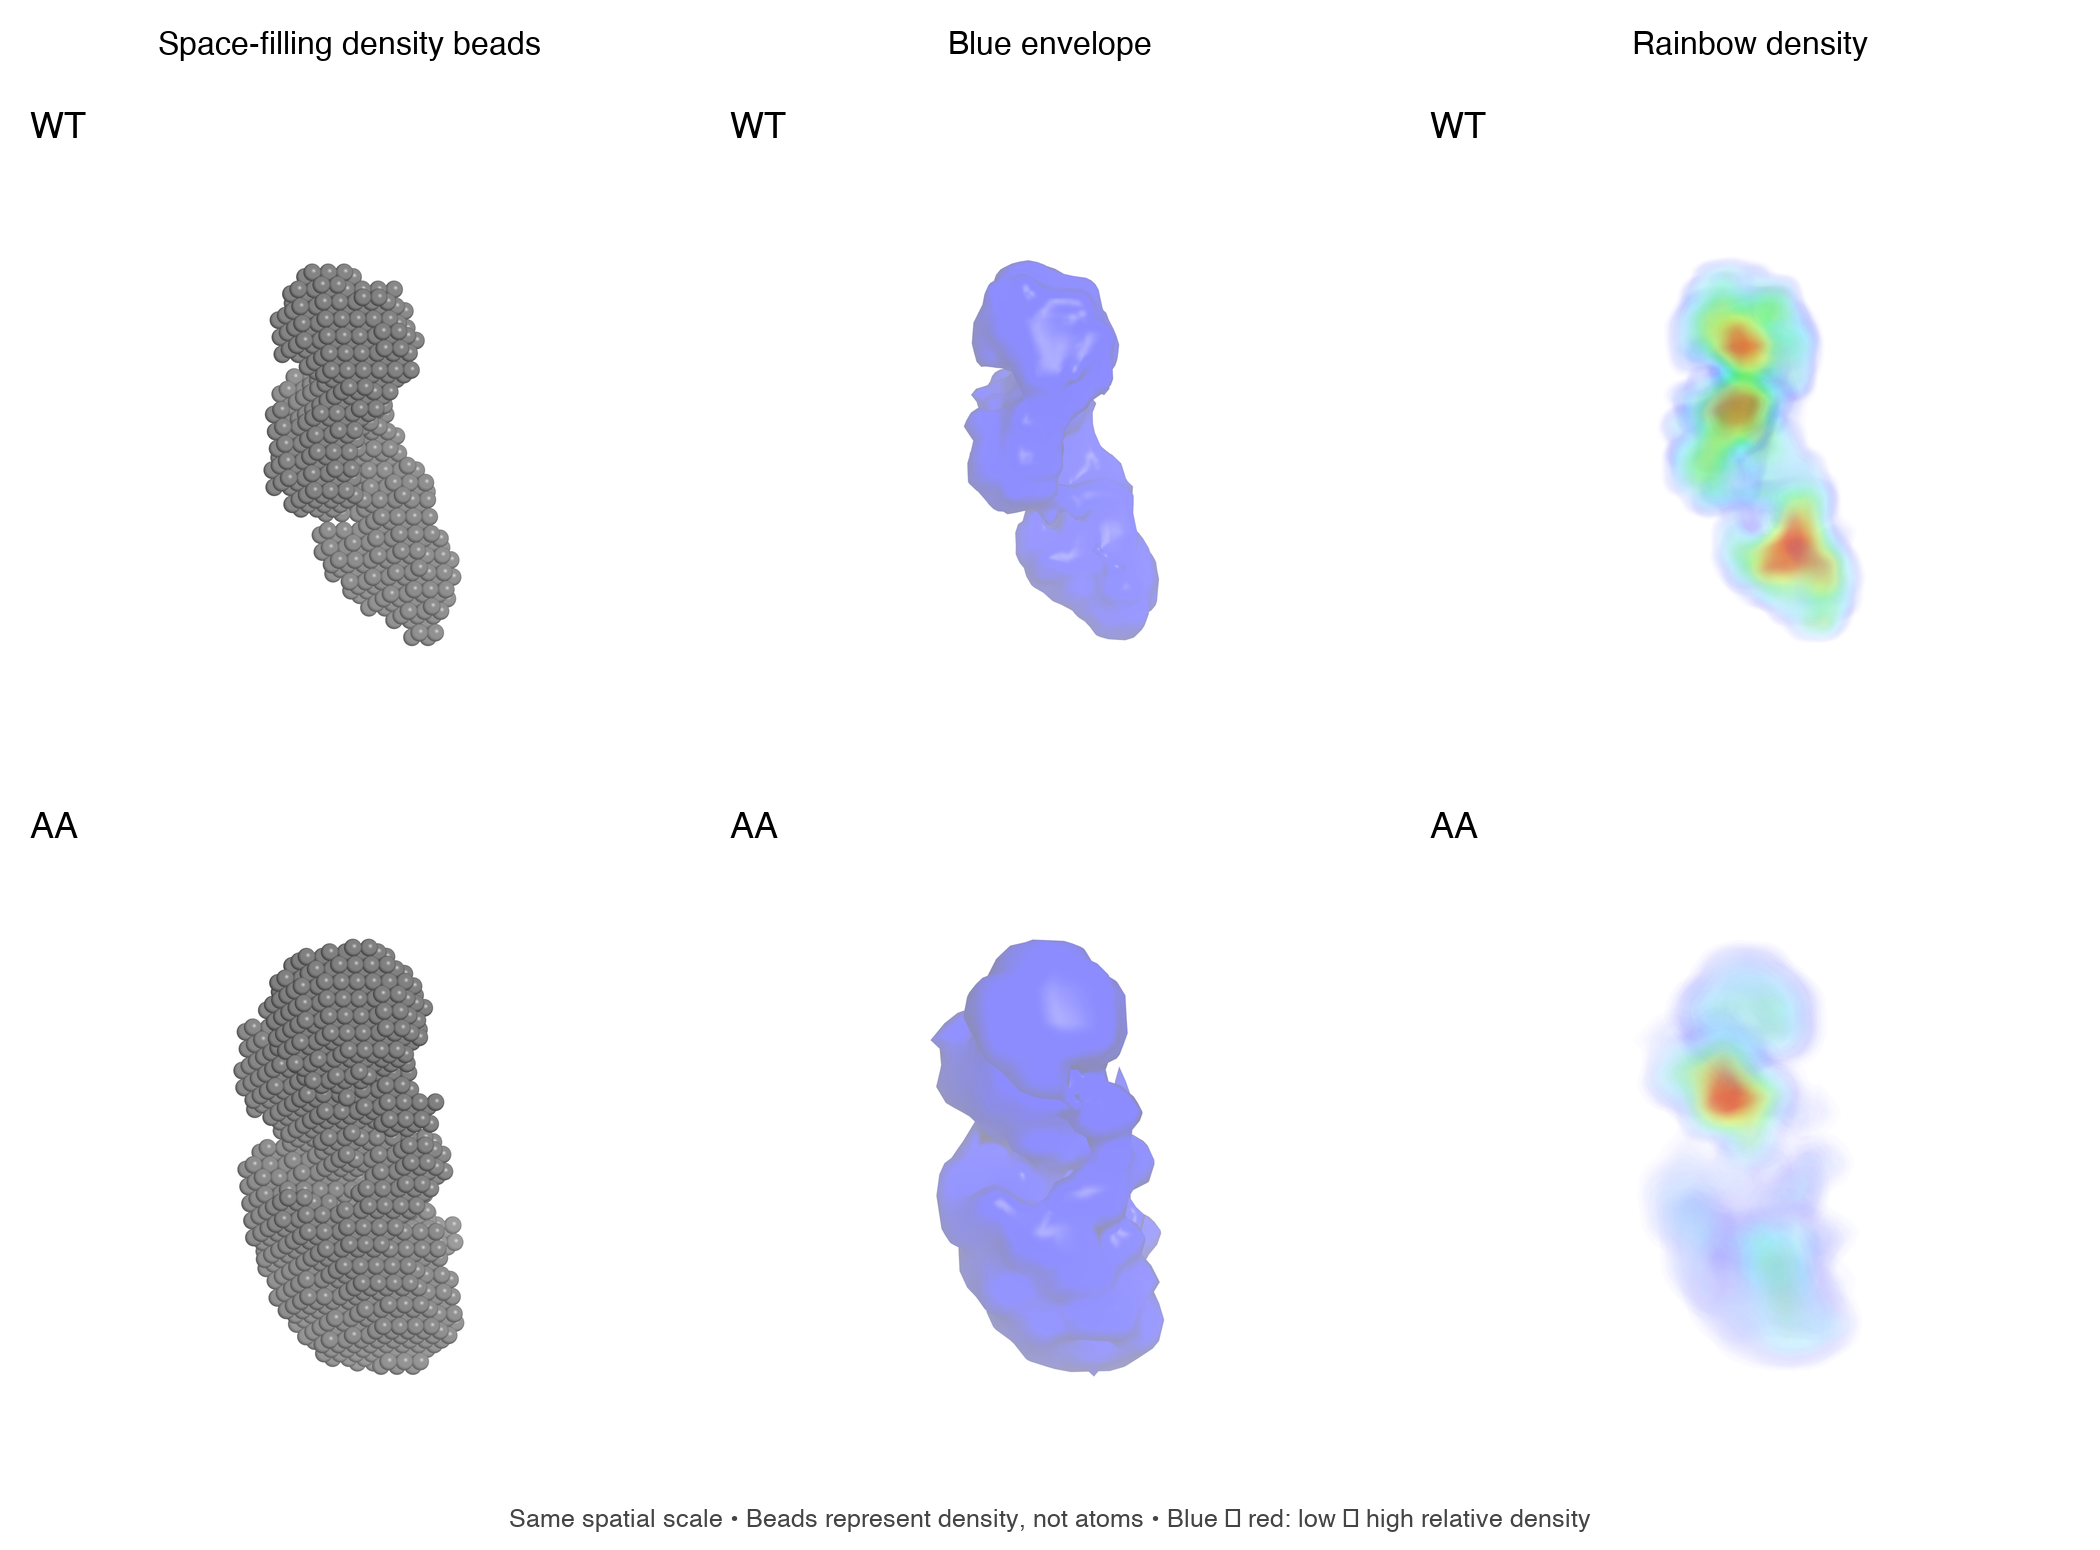

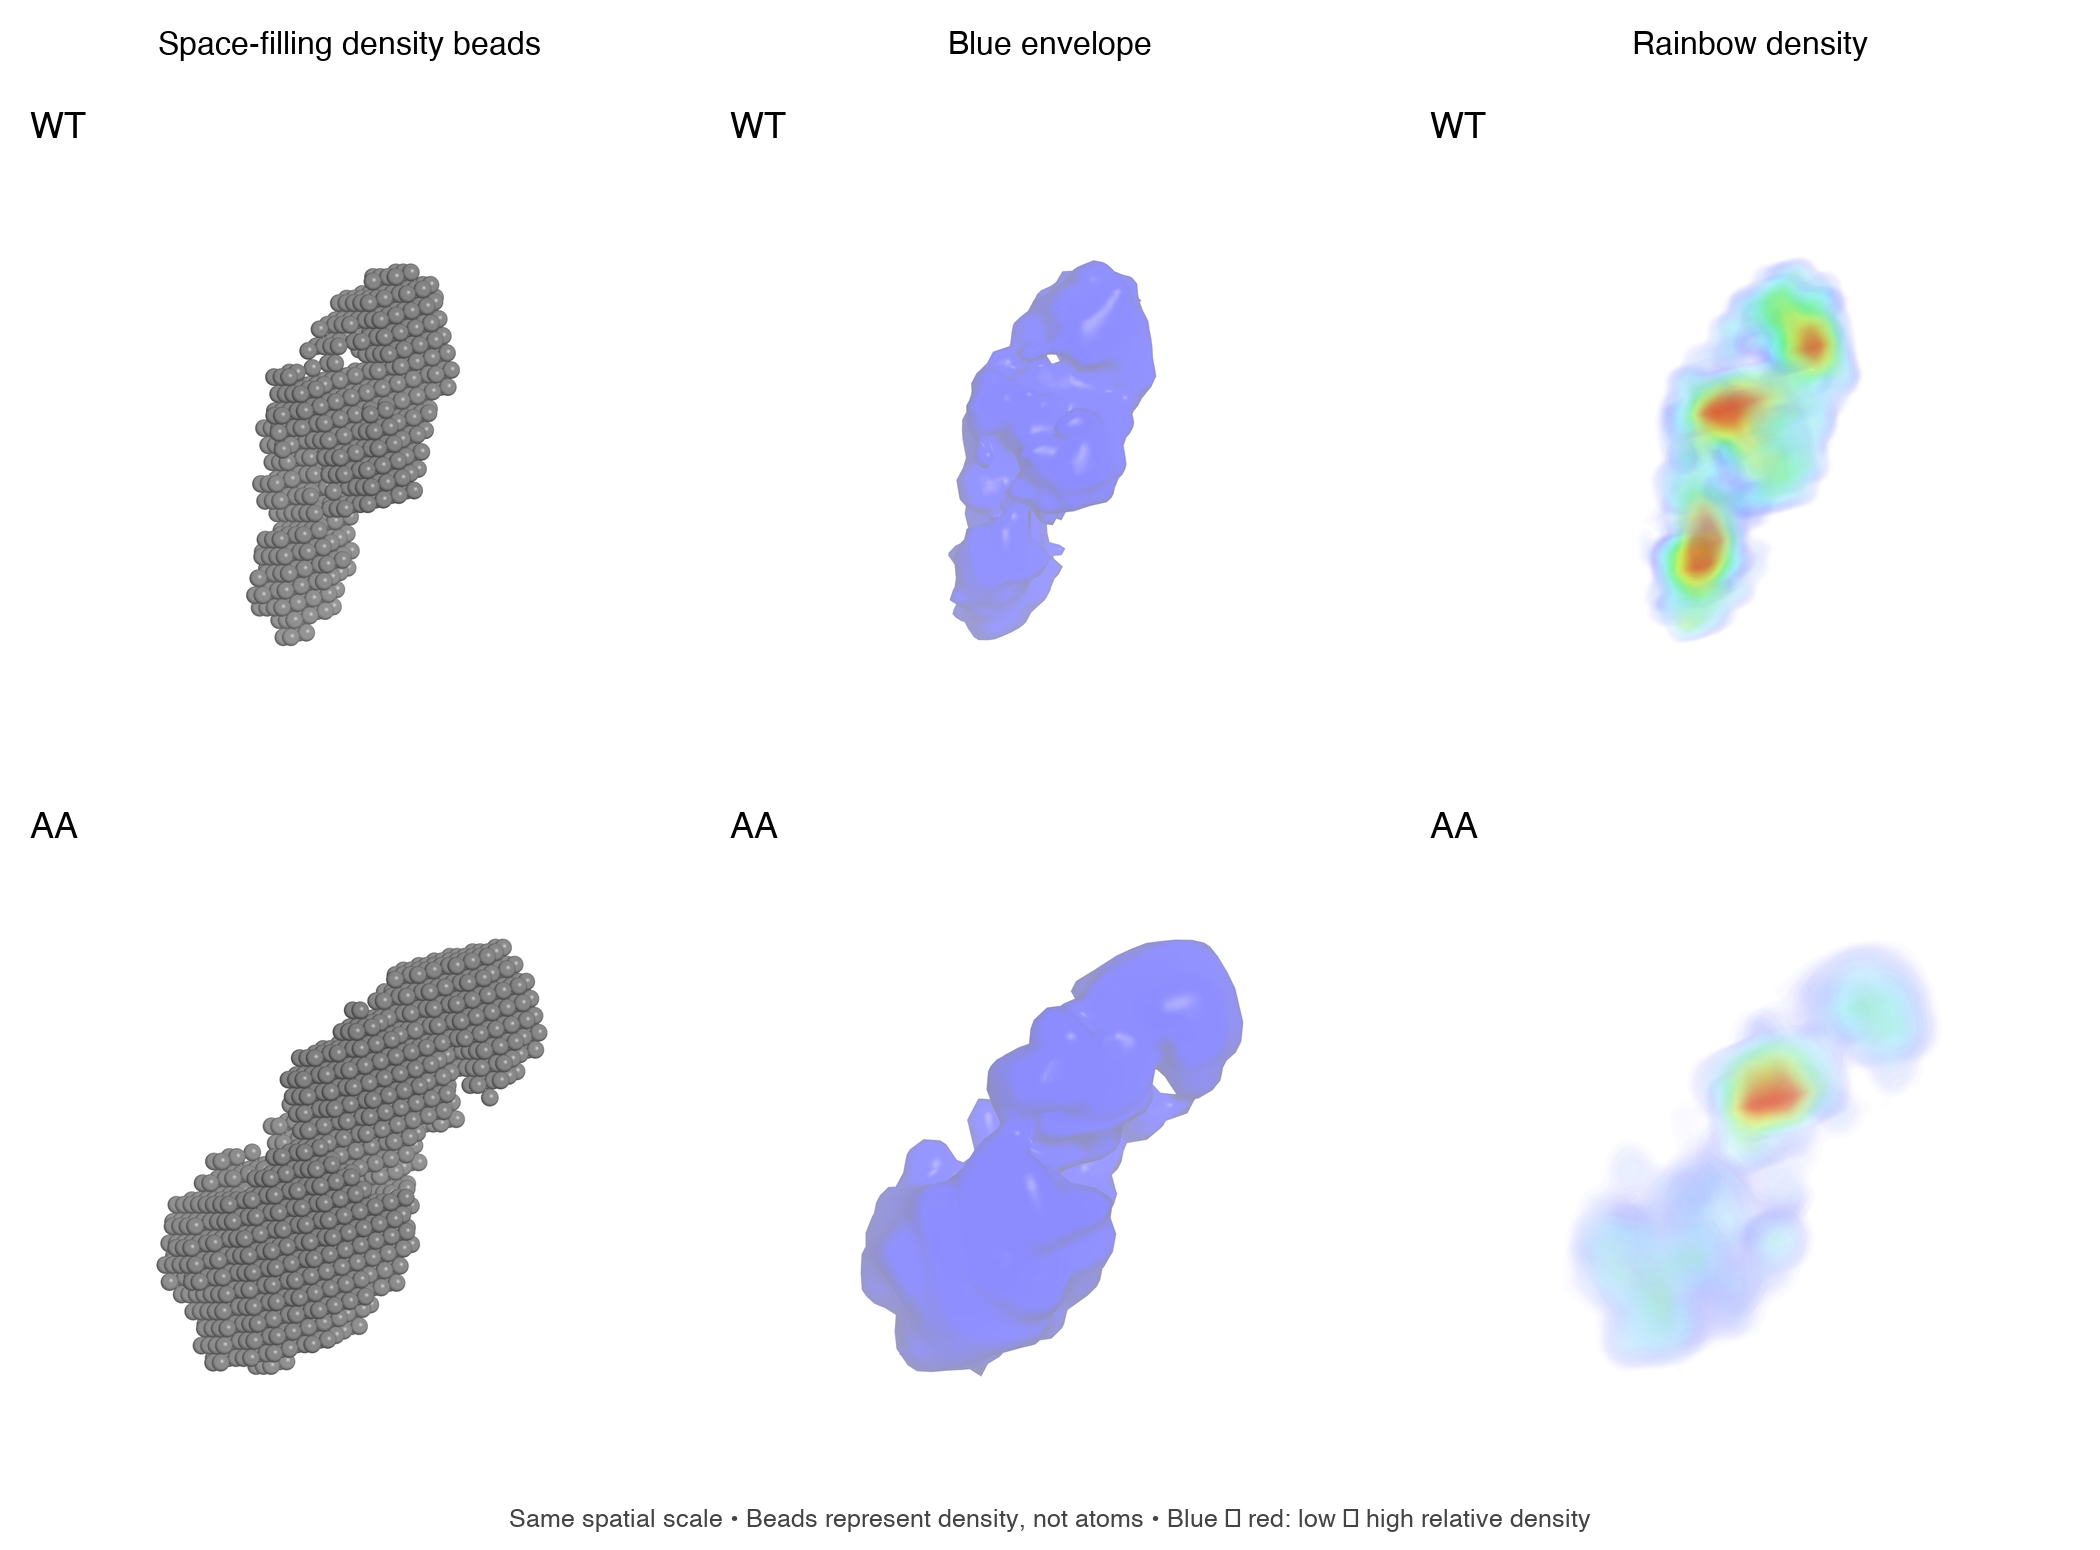

In [1]:
from pathlib import Path
from IPython.display import Image,display
for view in [1,2]:
    display(Image(filename=str(Path.cwd()/f'rainbow/DENSS_three_styles_view{view}.png'))) 

## Earlier supplementary rendering
The same refined MRC maps and 90% positive-density contours, with smooth lighting, unchanged mesh vertices, equal orthographic scale and50Åscale bars. [PDF](presentation/WT_AA_DENSS_presentation.pdf) · [Interactive view](presentation/DENSS_presentation_interactive.html).

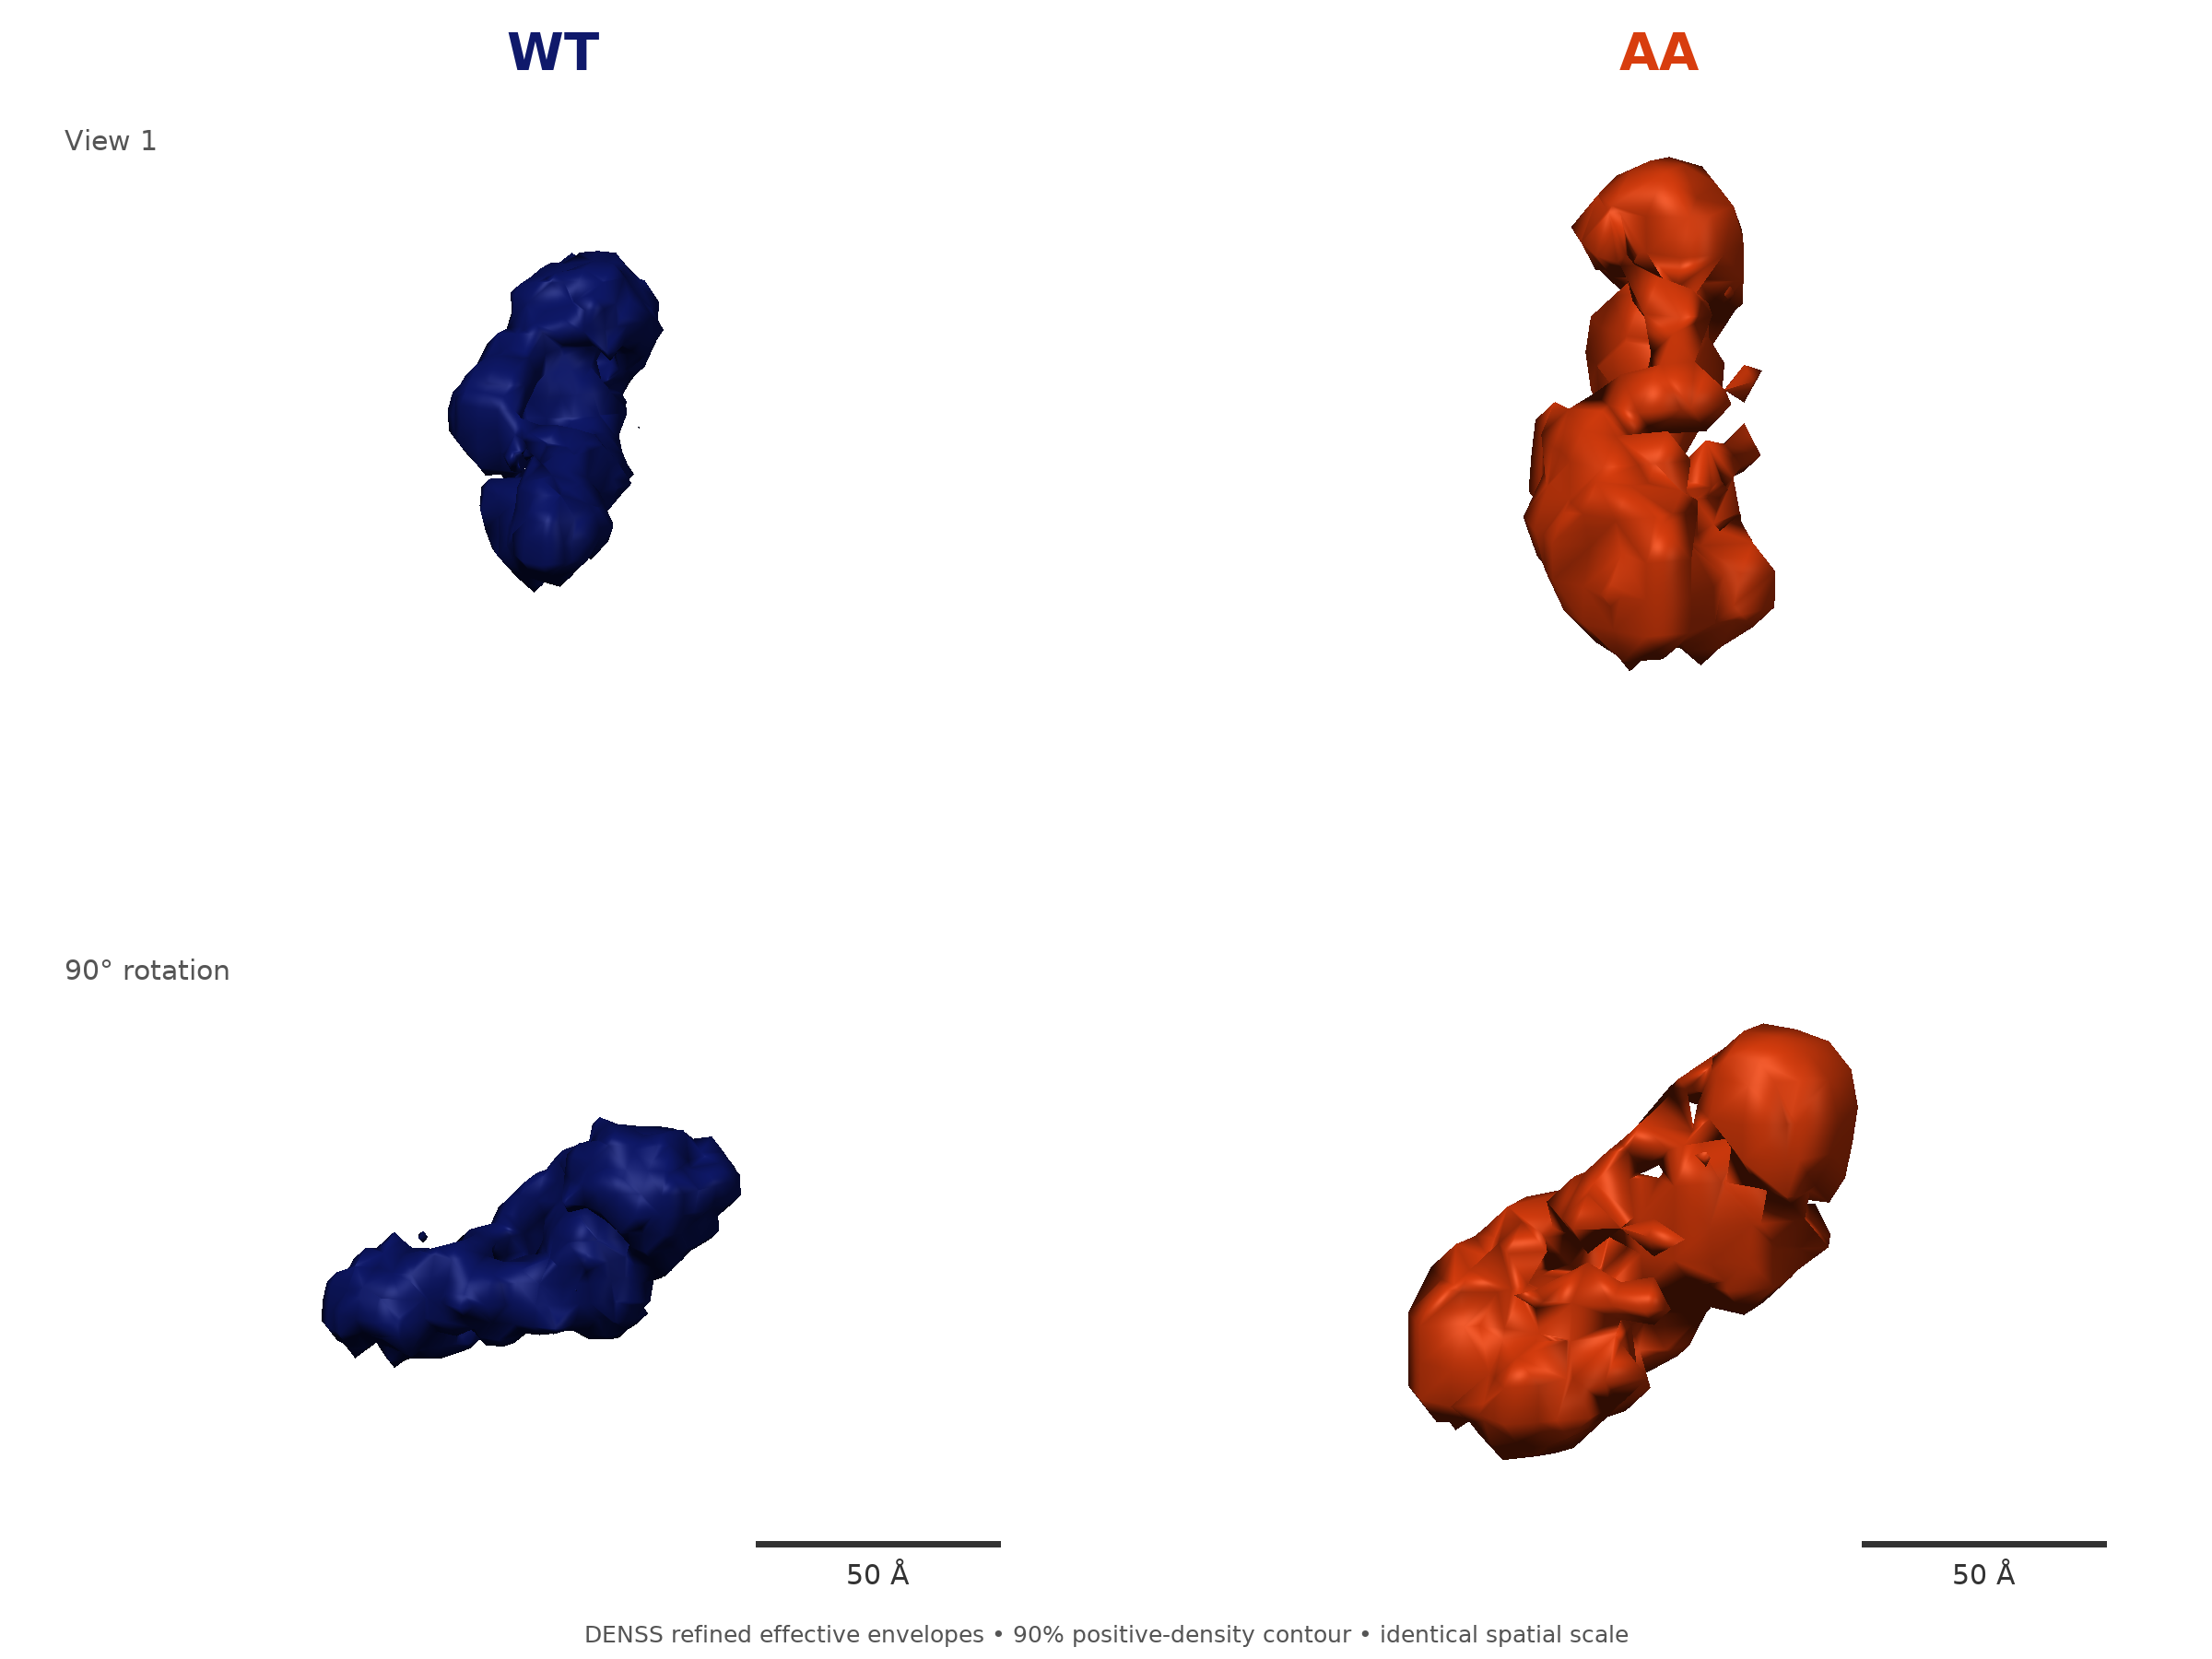

In [2]:
from pathlib import Path
from IPython.display import display,Image
display(Image(filename=str(Path.cwd()/'presentation/WT_AA_DENSS_presentation.png')))

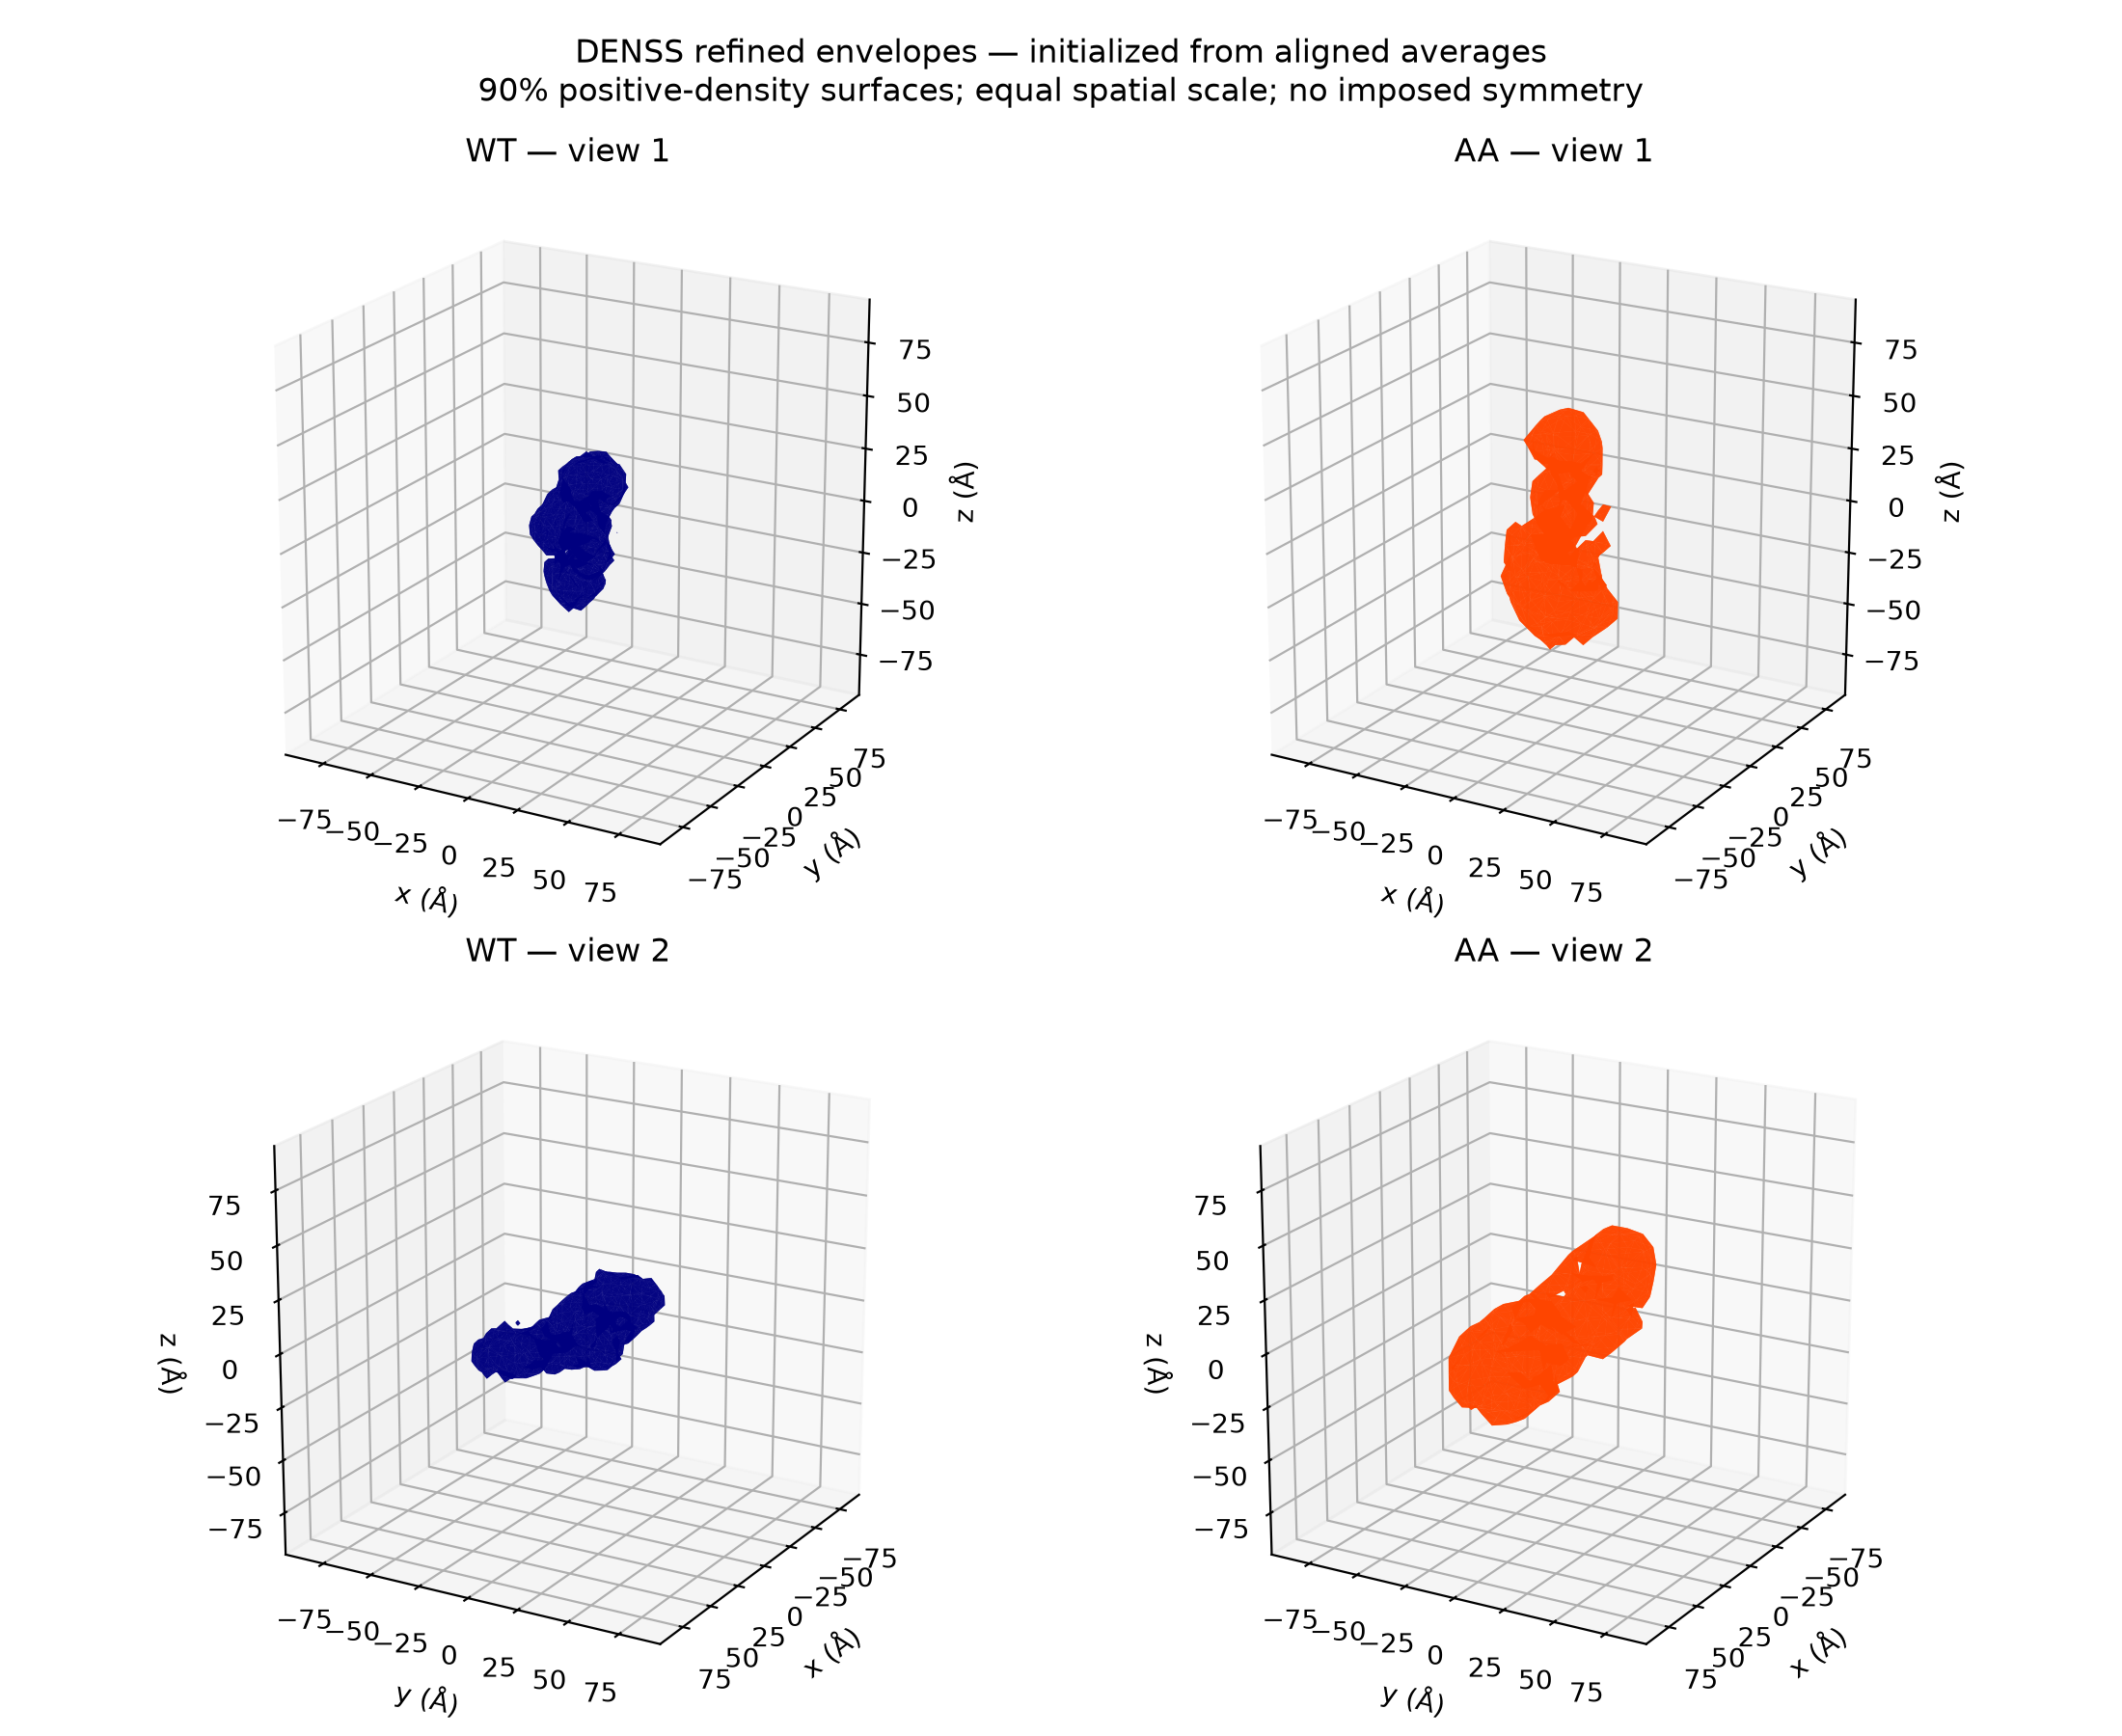

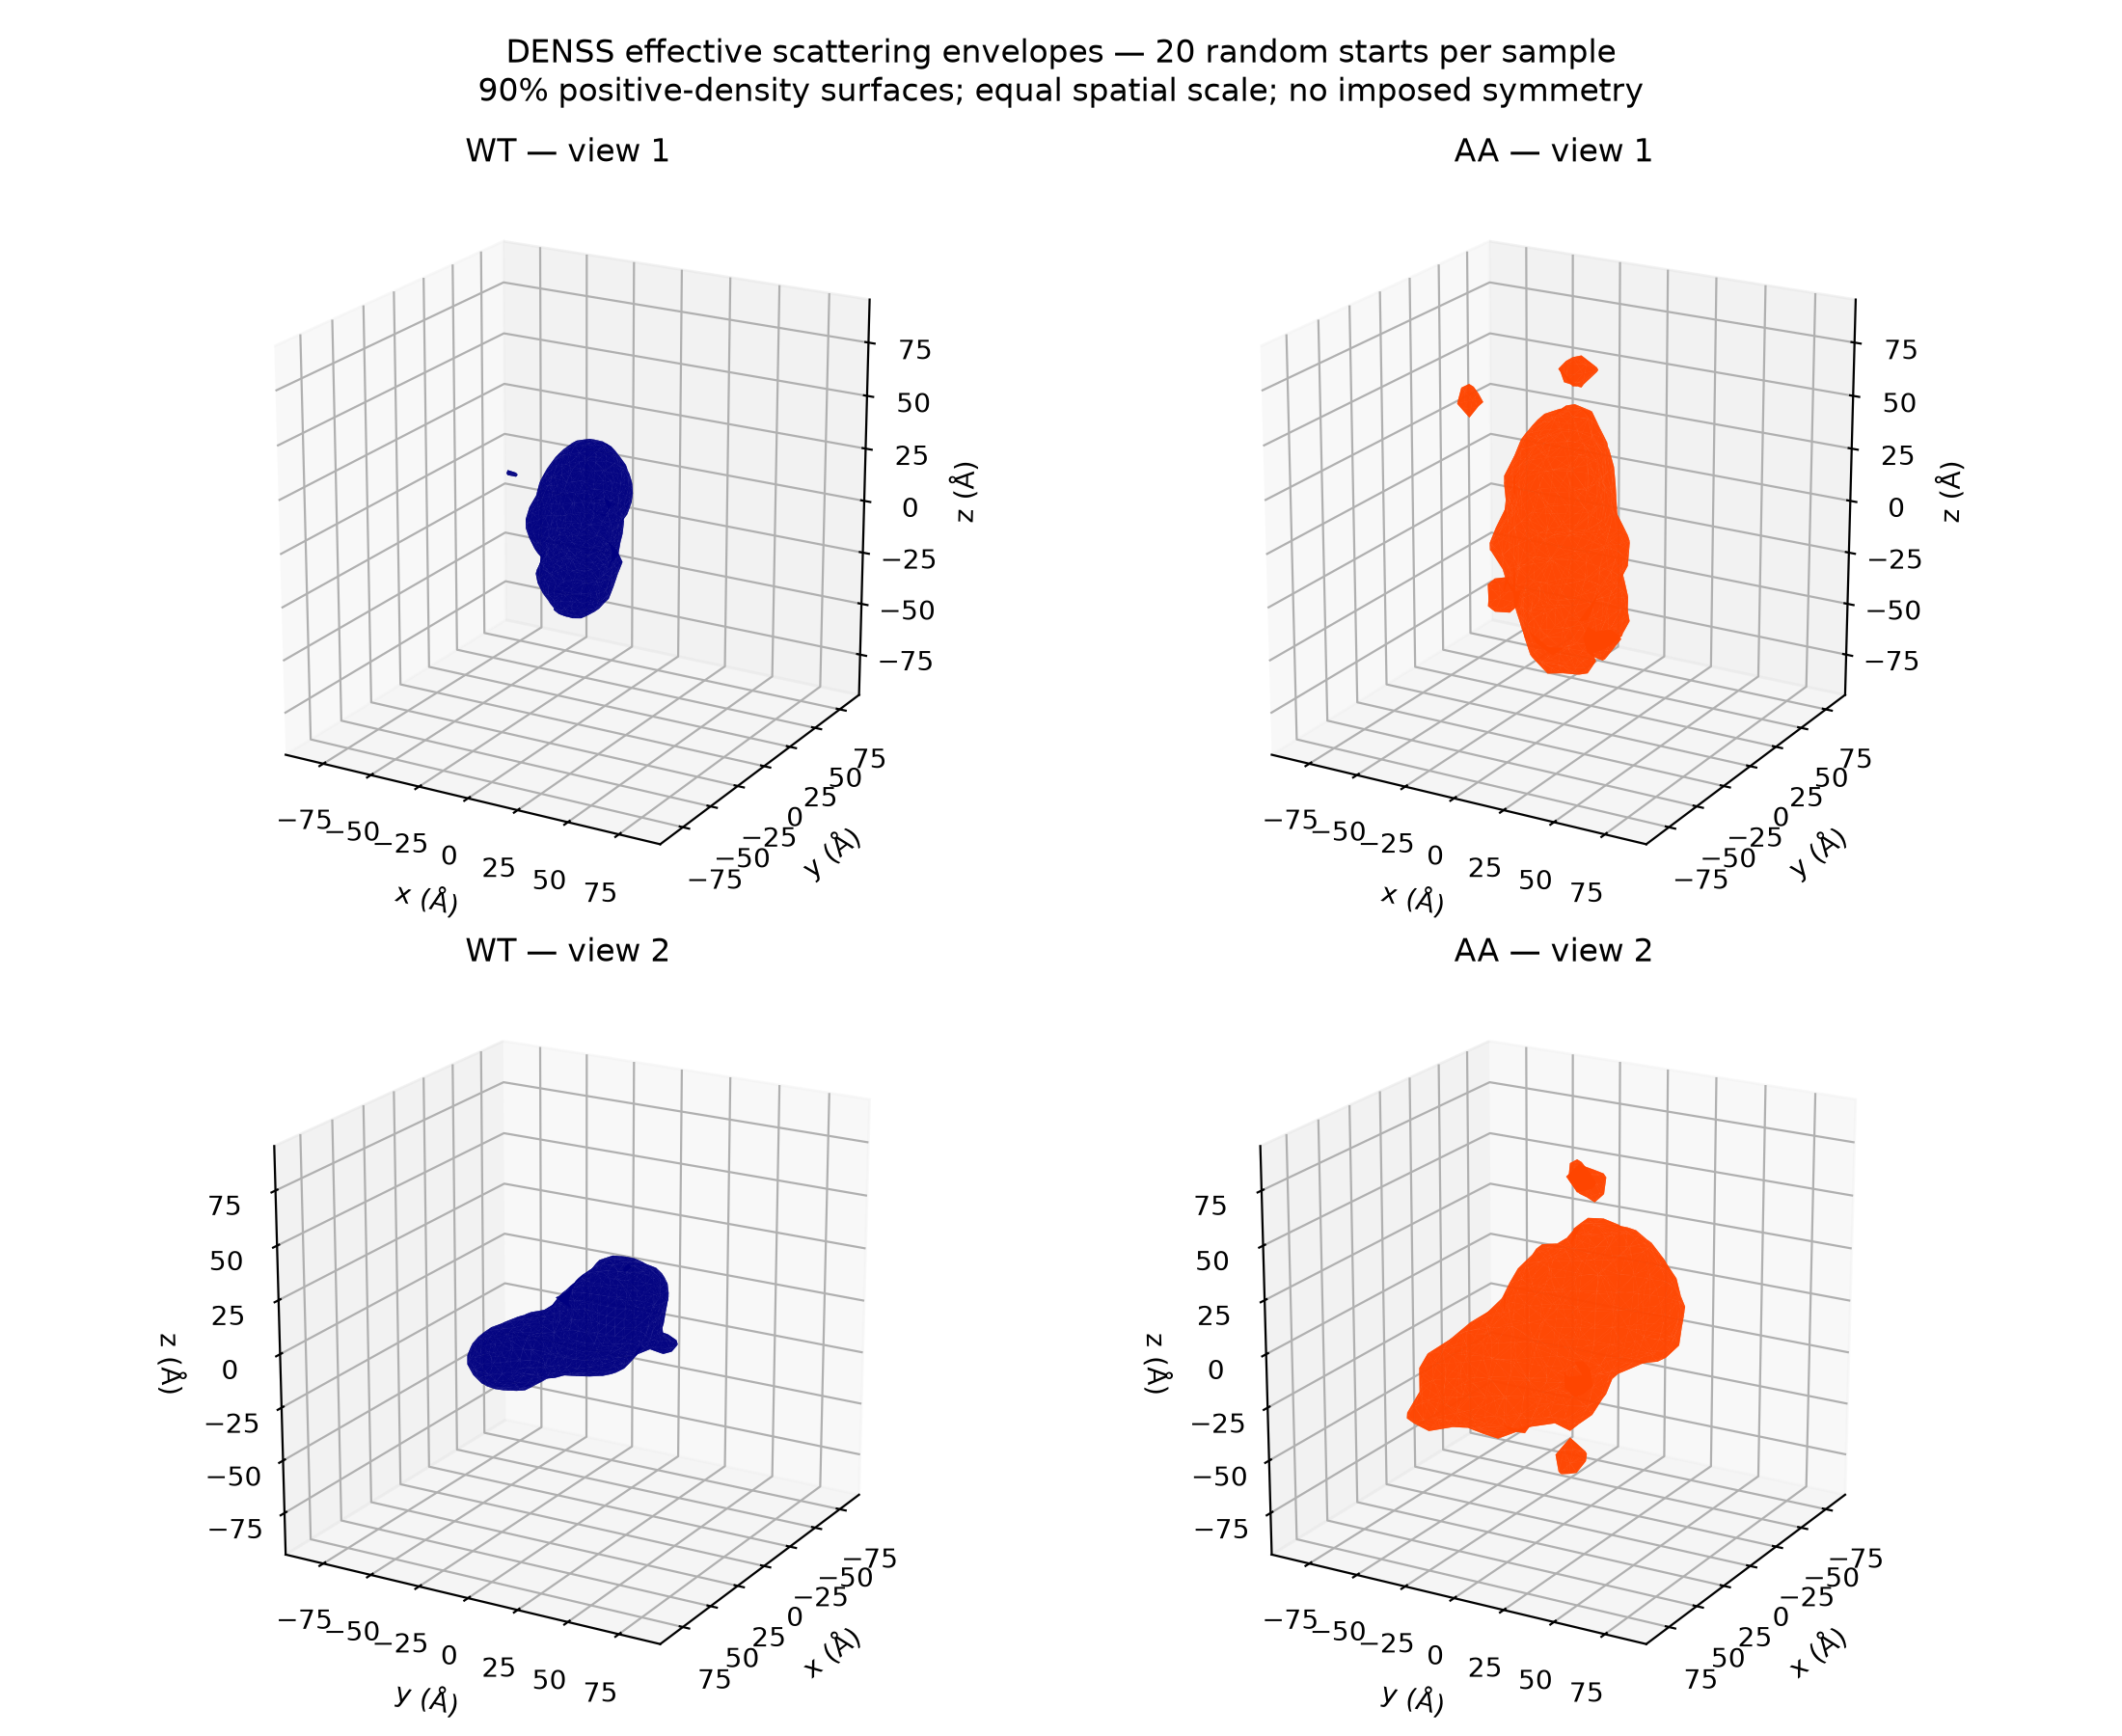

In [3]:
from pathlib import Path
import json
from IPython.display import display, Image, Markdown
ROOT=Path.cwd()
summary=json.loads((ROOT/'summary.json').read_text())
display(Image(filename=str(ROOT/'DENSS_refined_envelopes.png')))
display(Image(filename=str(ROOT/'DENSS_envelopes.png')))

## Agreement with measured scattering
Faint curves show all20individual reconstructions; the bold curve is the aligned average. Separate residual panels show the average (sample color) and refined map (green). The reported mean χ² is the mean squared normalized residual, not adjusted for the many effective reconstruction parameters.

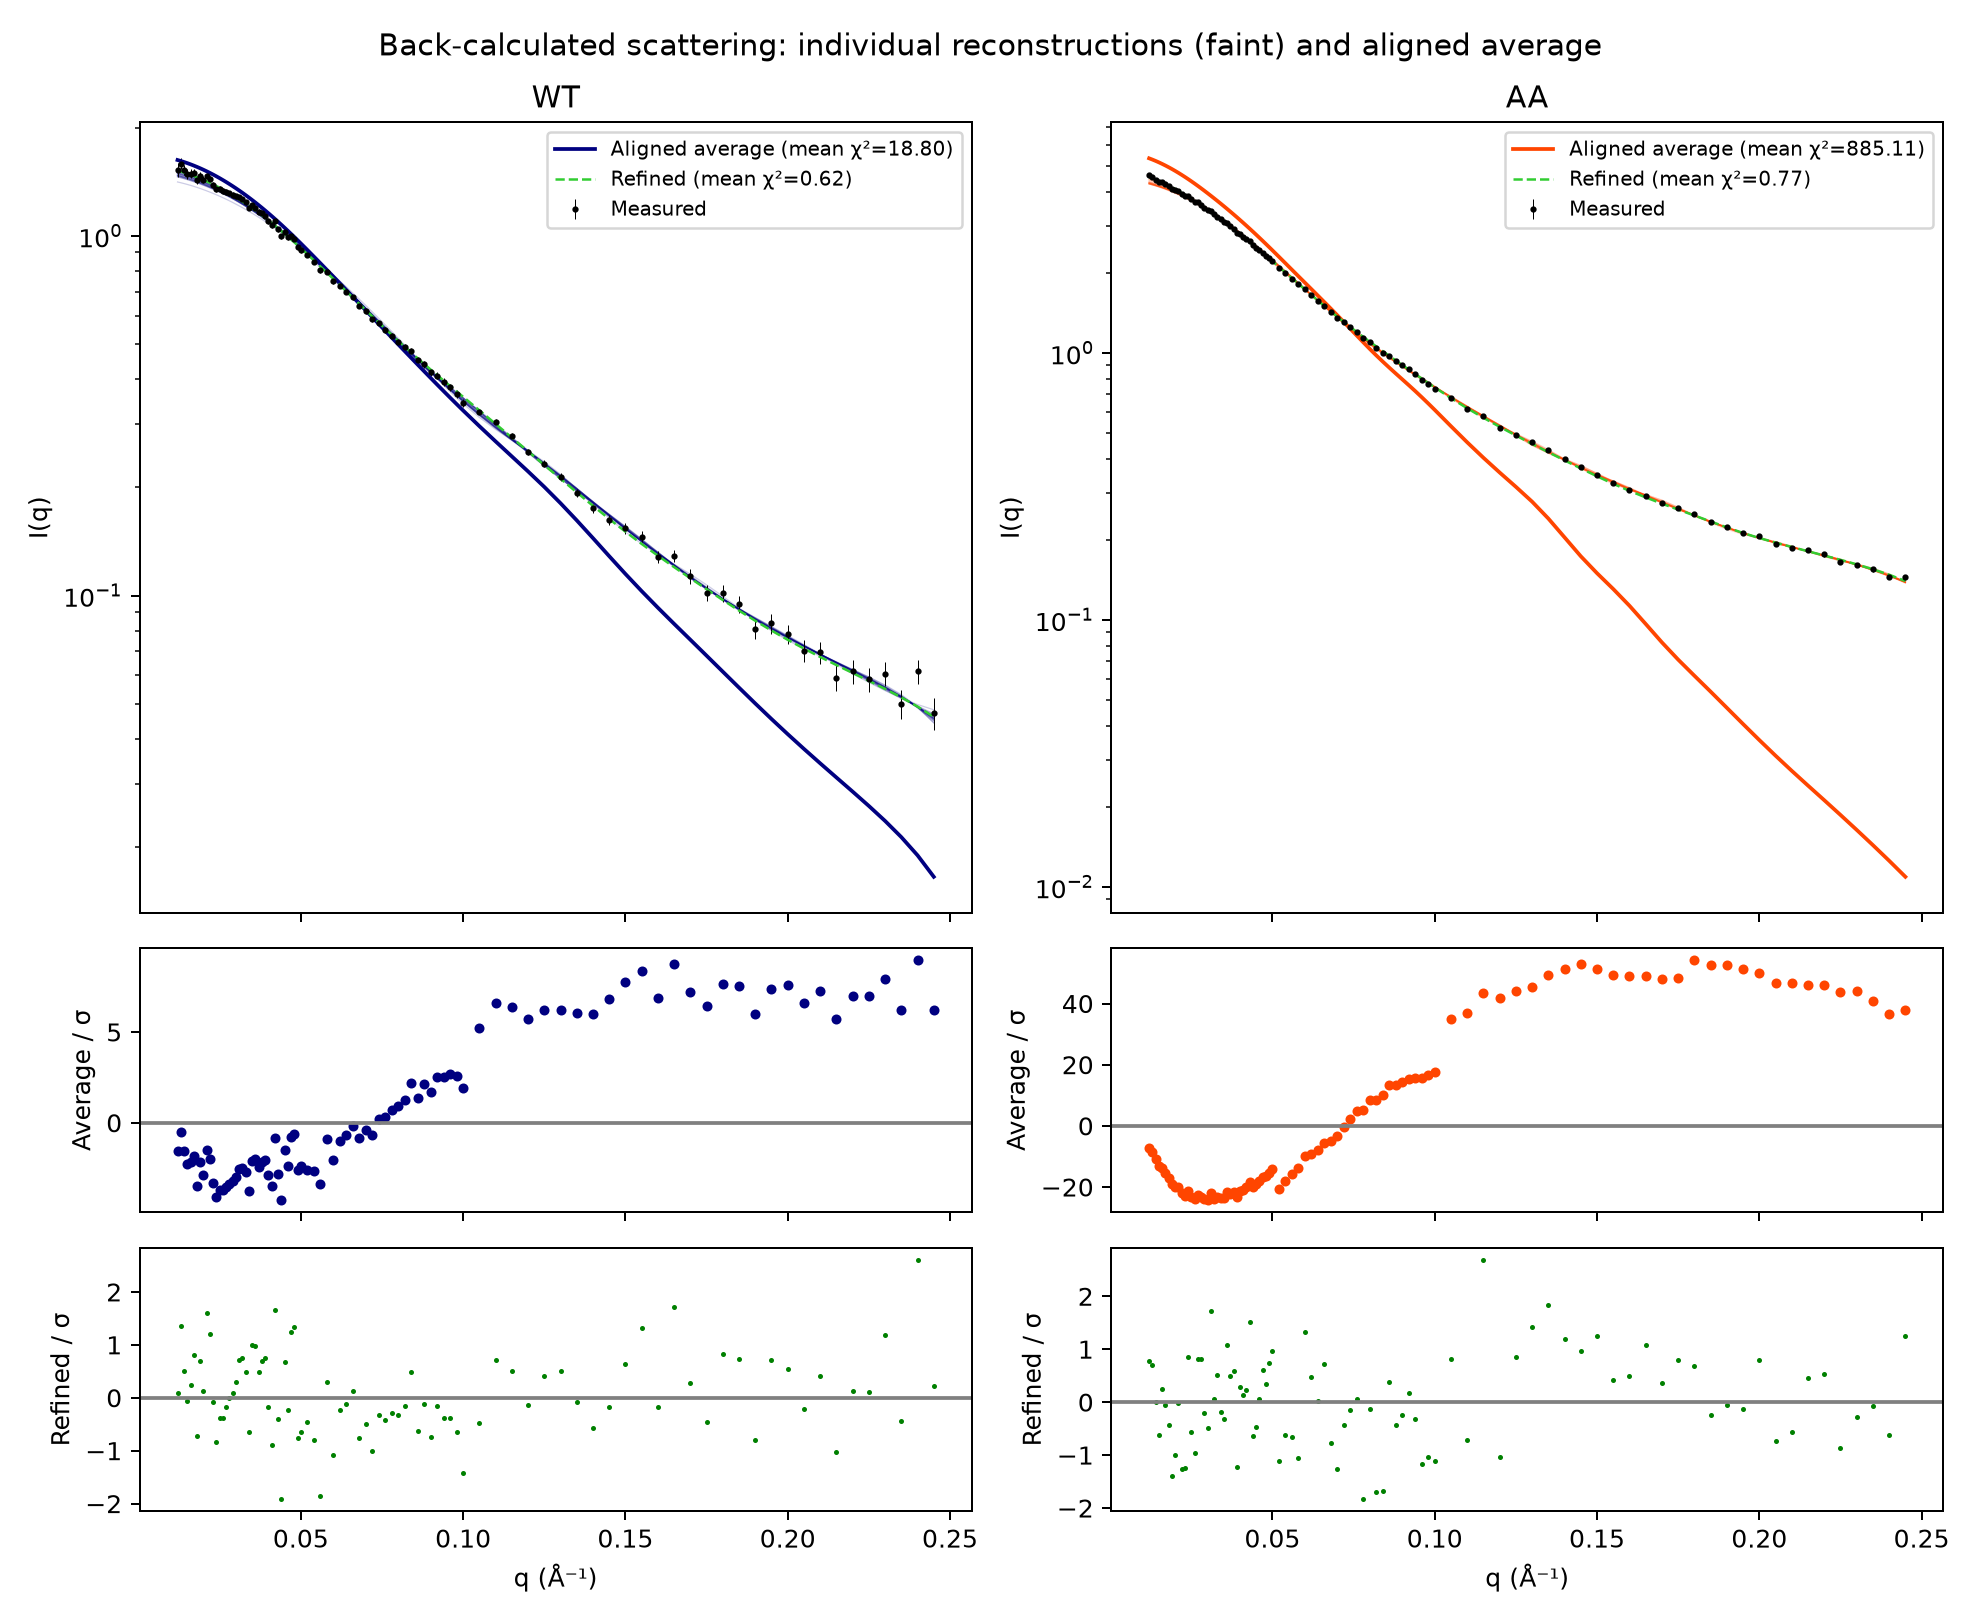

**WT**: individual mean χ² range 0.56–3.28; aligned-average mean χ² 18.80; refined mean χ² 0.62.

**AA**: individual mean χ² range 1.09–3.83; aligned-average mean χ² 885.11; refined mean χ² 0.77.

In [4]:
display(Image(filename=str(ROOT/'DENSS_fit_checks.png')))
for s,r in summary.items():
    x=r['individual_measured_mean_chi2']
    display(Markdown(f"**{s}**: individual mean χ² range {min(x):.2f}–{max(x):.2f}; aligned-average mean χ² {r['average_measured_mean_chi2']:.2f}; refined mean χ² {r['refined_measured_mean_chi2']:.2f}."))

## Interactive maps
Open [refined maps](DENSS_refined_interactive.html) or [aligned averages](DENSS_interactive.html) to rotate the two envelopes. Refined maps: [WT](WT_refined.mrc), [AA](AA_refined.mrc). Aligned averages: [WT](WT_avg.mrc), [AA](AA_avg.mrc).

In [5]:
for s,r in summary.items():
    print(s)
    print(r['alignment_log'])

WT
2026-09-23 14:04:29,528 - BEGIN
2026-09-23 14:04:29,528 - Command: /Users/f0044gk/Documents/Codex/2026-09-21/i-h/work/denss_runtime/denss/scripts/denss_all.py -f WT.dat -d 91.7257817 -m SLOW -nm 20 -j 4 --plot_off --write_freq 10000 -o WT_denss
2026-09-23 14:04:29,528 - DENSS Version: 1.8.7
2026-09-23 14:04:29,528 - Data filename: WT.dat
2026-09-23 14:04:29,529 - Enantiomer selection: True
2026-09-23 14:04:29,551 - Starting DENSS runs
2026-09-23 14:08:08,173 - Finished DENSS runs
2026-09-23 14:08:08,176 - Average |Rg|.............: 25.366 +- 0.622
2026-09-23 14:08:08,177 - Average Chi2.............: 1.183e+00 +- 5.708e-01
2026-09-23 14:08:08,177 - Average Support Volume...: 59424.755 +- 2262.585
2026-09-23 14:08:08,351 - Generating robust reference
2026-09-23 14:11:11,786 - Aligning all maps to reference
2026-09-23 14:11:48,645 - Correlation score to reference: WT_denss/WT_denss_0_aligned.mrc 0.871  
2026-09-23 14:11:48,651 - Correlation score to reference: WT_denss/WT_denss_1_align